# TASK 5: SALES PREDICTION USING PYTHON

## Internship Track: Data Science
## Internship Program: AICTE Oasis Infobyte Internship Program

### Objective

The objective of this project is to build a machine learning regression model that predicts product sales based on advertising expenditure across different media channels, including TV, Radio, and Newspaper.

### Technologies Used

- Python
- Google Colab / Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Dataset

The dataset contains advertising expenditure for TV, Radio, and Newspaper along with the corresponding Sales values. The dataset consists of 200 records and 4 variables used for analysis and prediction.

### Machine Learning Models

The following regression models were trained and compared:

1. Linear Regression
2. Random Forest Regressor

### Evaluation Metrics

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

## 1. Import Libraries and Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Advertising dataset
df = pd.read_csv('/content/Advertising.csv')

# Display the first five rows
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 2. Data Understanding and Cleaning

In [4]:
# Remove the unnecessary index column
df = df.drop(columns=['Unnamed: 0'])

# Check the number of rows and columns
print("Number of rows and columns:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Number of rows and columns: (200, 4)

Column names:
['TV', 'Radio', 'Newspaper', 'Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
# Check for missing values in each column
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


## 3. Descriptive Statistics

In [6]:
# Display descriptive statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 4. Exploratory Data Analysis (EDA)

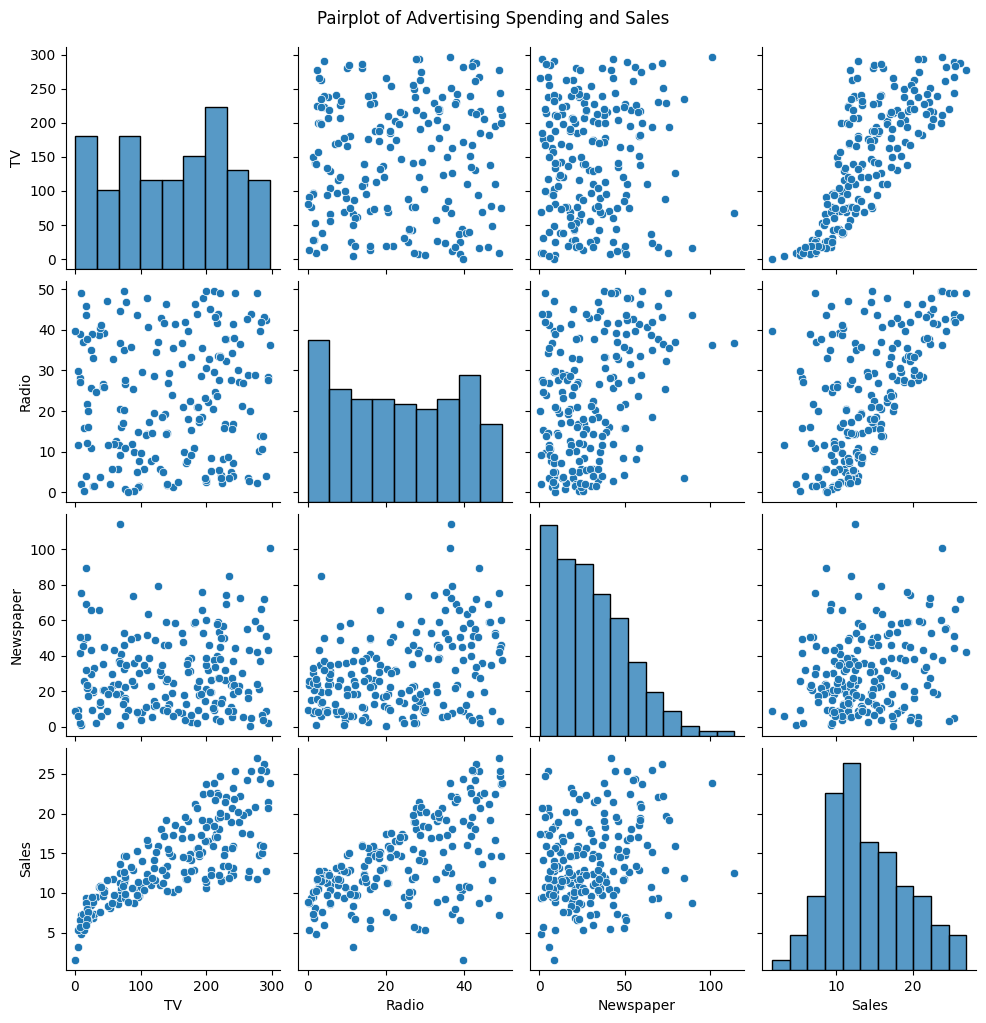

In [7]:
# Create a pairplot to visualize relationships between all variables
sns.pairplot(df)

plt.suptitle('Pairplot of Advertising Spending and Sales', y=1.02)

plt.show()

### 4.1 Individual Advertising Channel Analysis

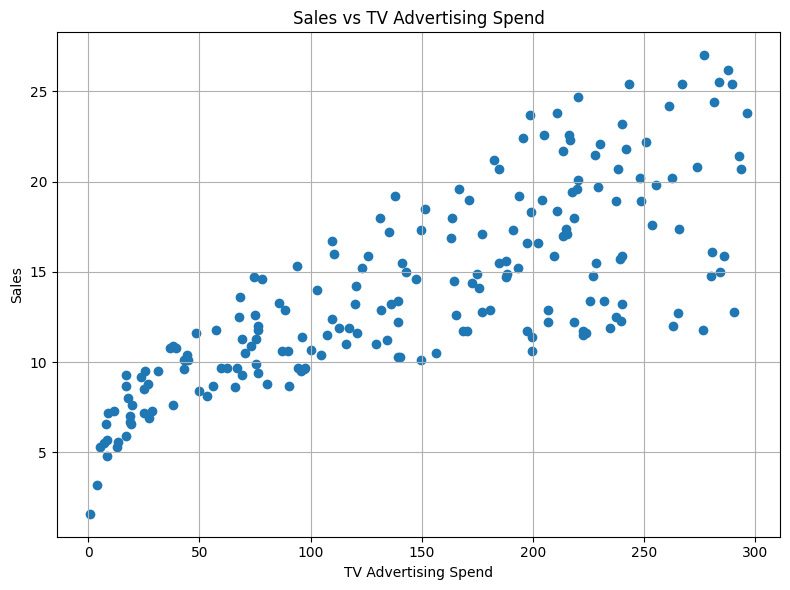

In [8]:
# Sales vs TV Advertising Spend
plt.figure(figsize=(8, 6))

plt.scatter(df['TV'], df['Sales'])

plt.title('Sales vs TV Advertising Spend')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')

plt.grid(True)
plt.tight_layout()
plt.show()

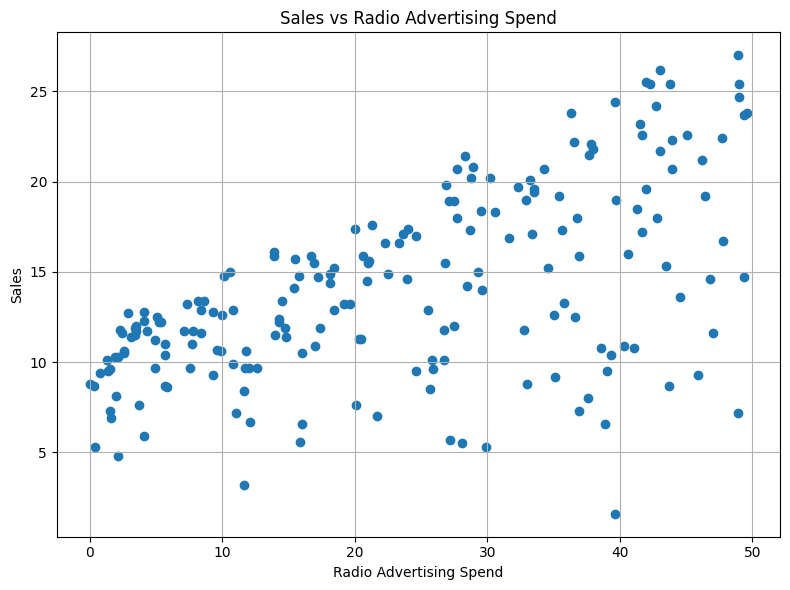

In [9]:
# Sales vs Radio Advertising Spend
plt.figure(figsize=(8, 6))

plt.scatter(df['Radio'], df['Sales'])

plt.title('Sales vs Radio Advertising Spend')
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')

plt.grid(True)
plt.tight_layout()
plt.show()

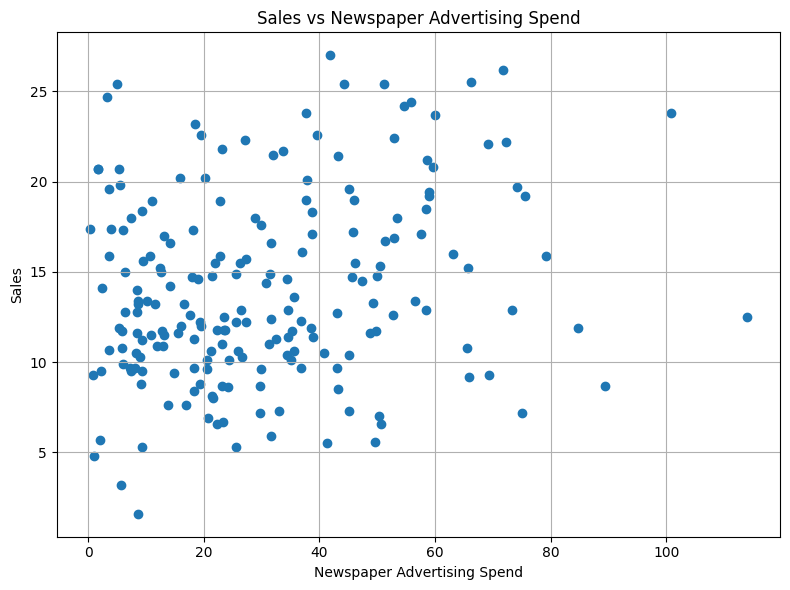

In [10]:
# Sales vs Newspaper Advertising Spend
plt.figure(figsize=(8, 6))

plt.scatter(df['Newspaper'], df['Sales'])

plt.title('Sales vs Newspaper Advertising Spend')
plt.xlabel('Newspaper Advertising Spend')
plt.ylabel('Sales')

plt.grid(True)
plt.tight_layout()
plt.show()

### 4.2 Correlation Analysis

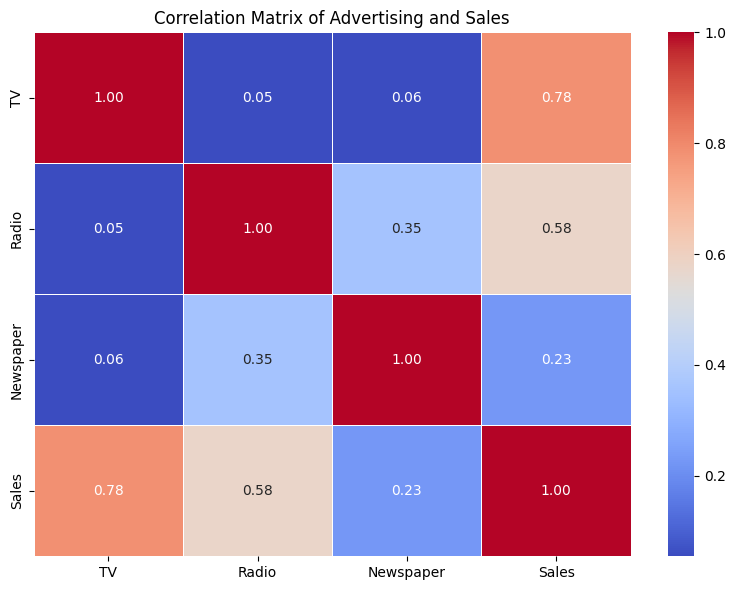

In [5]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Advertising and Sales')

plt.tight_layout()
plt.show()

## 5. Machine Learning Model Development

In [6]:
from sklearn.model_selection import train_test_split

# Define the input features
X = df[['TV', 'Radio', 'Newspaper']]

# Define the target variable
y = df['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (160, 3)
Testing features: (40, 3)
Training target: (160,)
Testing target: (40,)


### 5.1 Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)

# Display the first 10 predictions
print("First 10 Linear Regression Predictions:")
print(linear_predictions[:10])

First 10 Linear Regression Predictions:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


### 5.2 Random Forest Regressor

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest Regressor model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test data
rf_predictions = rf_model.predict(X_test)

# Display the first 10 predictions
print("First 10 Random Forest Predictions:")
print(rf_predictions[:10])

First 10 Random Forest Predictions:
[17.698 21.804 20.628  6.793 22.927 13.379 22.376  9.688 11.826 15.54 ]


## 6. Model Evaluation and Comparison

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate Linear Regression
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

# Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

# Create a comparison table
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [linear_mae, rf_mae],
    'RMSE': [linear_rmse, rf_rmse],
    'R² Score': [linear_r2, rf_r2]
})

# Display the results
print("Model Performance Comparison:")
display(model_results)

Model Performance Comparison:


,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


### Model Performance Observation

The performance of Linear Regression and Random Forest Regressor was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The Random Forest Regressor performed better than Linear Regression across all three evaluation metrics. It achieved the lowest MAE of 0.620100 and the lowest RMSE of 0.768591, indicating lower prediction errors. It also achieved the highest R² Score of 0.981284, showing that the model explains approximately 98.13% of the variation in sales in the test dataset.

Therefore, the Random Forest Regressor is selected as the best-performing model for predicting sales in this project.

## 7. Feature Importance Analysis

Feature Importance:


,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


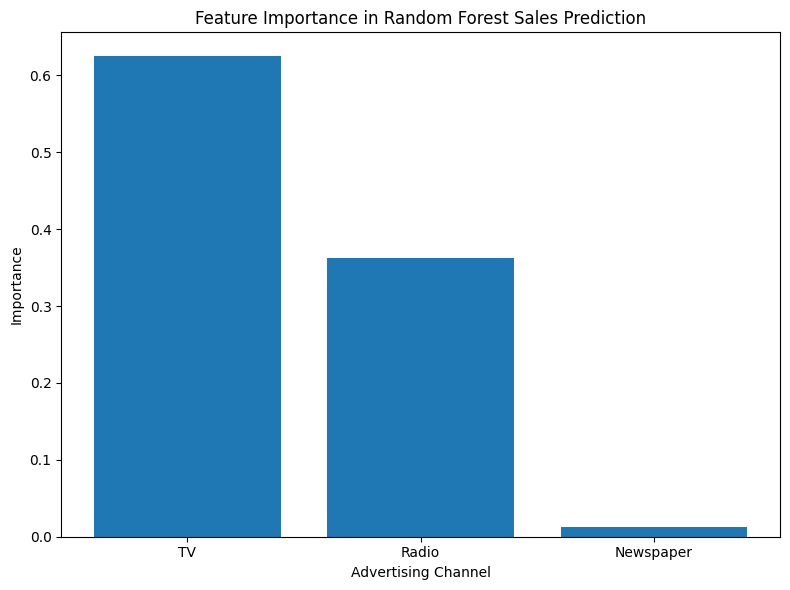

In [10]:
# Get feature importance from the Random Forest model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance values
print("Feature Importance:")
display(feature_importance)

# Create the feature importance chart
plt.figure(figsize=(8, 6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance in Random Forest Sales Prediction')
plt.xlabel('Advertising Channel')
plt.ylabel('Importance')

plt.tight_layout()
plt.show()

### Feature Importance Observation

The feature importance analysis of the Random Forest Regressor shows that TV advertising has the highest importance, with a value of 0.624810. Radio is the second most important feature, with an importance value of 0.362201. Newspaper has the lowest importance, with a value of 0.012989.

Therefore, TV advertising has the highest impact on the model's sales predictions, followed by Radio. Newspaper contributes relatively little to the predictive performance of the Random Forest model.

# Conclusion

In this project, a machine learning model was developed to predict product sales based on advertising expenditure across TV, Radio, and Newspaper channels.

The dataset was first explored using descriptive statistics and visualizations, including pairplots, scatter plots, and a correlation heatmap. The data was then divided into training and testing sets using an 80/20 split.

Two regression models were trained and evaluated: Linear Regression and Random Forest Regressor. The models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The Random Forest Regressor performed better than Linear Regression, achieving an MAE of 0.620100, an RMSE of 0.768591, and an R² Score of 0.981284. Therefore, Random Forest was selected as the best-performing model.

The feature importance analysis showed that TV advertising had the highest importance (0.624810), followed by Radio (0.362201), while Newspaper had the lowest importance (0.012989). Based on the model's feature importance, TV advertising was the most influential advertising channel for predicting sales in this dataset.

Overall, the project demonstrates how machine learning and data analysis can be used to understand the relationship between advertising expenditure and sales and to build a model for sales prediction.